In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ЭТАП 1: Анализ данных (EDA)

In [2]:
#1.	Загрузить house.csv, вывести 10 строк.
db = pd.read_csv('house.csv')
db.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [3]:
#2.	Посмотреть .info() и .shape.
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
db.shape

(1460, 81)

In [5]:
#3.	Вывести список колонок и их типы.
db.dtypes

,0
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
...,...
MoSold,int64
YrSold,int64
SaleType,object
SaleCondition,object


In [6]:
#колонка
db.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [7]:
#4.	Удалить все неиспользуемые признаки (оставить только нужные 7 + SalePrice).
db = db[['GrLivArea', 'YearBuilt', 'GarageCars', 'TotalBsmtSF', 'FullBath',
         'OverallQual', 'Neighborhood', 'SalePrice']]

In [8]:
db

,GrLivArea,YearBuilt,GarageCars,TotalBsmtSF,FullBath,OverallQual,Neighborhood,SalePrice
0,1710,2003,2,856,2,7,CollgCr,208500
1,1262,1976,2,1262,2,6,Veenker,181500
2,1786,2001,2,920,2,7,CollgCr,223500
3,1717,1915,3,756,1,7,Crawfor,140000
4,2198,2000,3,1145,2,8,NoRidge,250000
...,...,...,...,...,...,...,...,...
1455,1647,1999,2,953,2,6,Gilbert,175000
1456,2073,1978,2,1542,2,6,NWAmes,210000
1457,2340,1941,1,1152,2,7,Crawfor,266500
1458,1078,1950,1,1078,1,5,NAmes,142125


In [9]:
#5.	Сохранить облегчённый датасет в отдельный CSV (data_clean.csv).
db.to_csv('db_clean_csv', index=False)

In [10]:
#6.	Сколько уникальных районов (Neighborhood)?
db['Neighborhood'].nunique()

25

In [11]:
#7.	Средняя цена по району — топ 5 дорогих районов.
db.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False).head(5).round()

,SalePrice
Neighborhood,
NoRidge,335295.0
NridgHt,316271.0
StoneBr,310499.0
Timber,242247.0
Veenker,238773.0


In [12]:
#8.	Сколько домов было построено после 2000 года?
count = db[db['YearBuilt'] > 2000].shape[0]
print(f'домов было построено после 2000 года: {count}')

домов было построено после 2000 года: 364


In [13]:
#9.	Средняя жилая площадь (GrLivArea) по уровню качества (OverallQual).
db.groupby('OverallQual')['GrLivArea'].mean().round()

,GrLivArea
OverallQual,
1,619.0
2,573.0
3,1119.0
4,1107.0
5,1251.0
6,1466.0
7,1704.0
8,1948.0
9,2078.0


In [14]:
#10.	Есть ли дома с нулевым подвалом? Посчитать долю таких домов.
count = db[db['TotalBsmtSF'] == 0].shape[0]
print(count)

37


In [15]:
total_house = db['TotalBsmtSF'].shape[0]

In [16]:
print(f'{round((count * 100) / total_house, 2)} % ')

2.53 % 


In [17]:
#11.	Группировка по GarageCars и средняя цена.
db.groupby('GarageCars')['SalePrice'].mean().round()

,SalePrice
GarageCars,
0,103317.0
1,128117.0
2,183852.0
3,309636.0
4,192656.0


In [18]:
#12.	Сколько домов имеют 2+ ванных комнаты (FullBath)?
count = db[db['FullBath'] > 2].shape[0]
print(count)

33


In [19]:
#13.	Район с наибольшим количеством домов.
db['Neighborhood'].value_counts().head(1)

,count
Neighborhood,
NAmes,225


In [20]:
##14.	Корреляция GrLivArea, TotalBsmtSF, OverallQual, GarageCars с SalePrice.
new_db = db[['GrLivArea', 'TotalBsmtSF', 'OverallQual', 'GarageCars', 'SalePrice']]
new_db.corr()

,GrLivArea,TotalBsmtSF,OverallQual,GarageCars,SalePrice
GrLivArea,1.000000,0.454868,0.593007,0.467247,0.708624
TotalBsmtSF,0.454868,1.000000,0.537808,0.434585,0.613581
OverallQual,0.593007,0.537808,1.000000,0.600671,0.790982
GarageCars,0.467247,0.434585,0.600671,1.000000,0.640409
SalePrice,0.708624,0.613581,0.790982,0.640409,1.000000


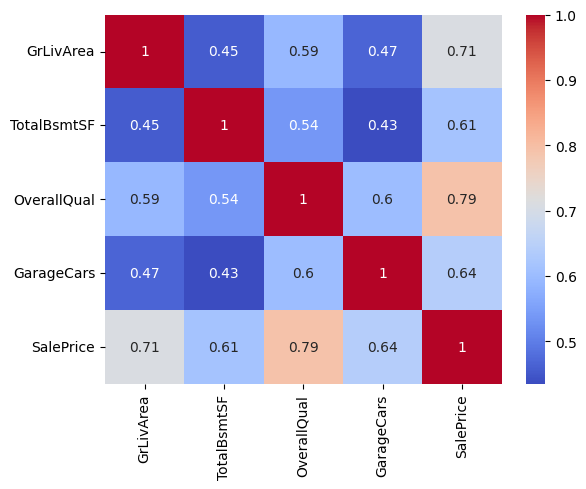

In [21]:
sns.heatmap(new_db.corr(), annot=True, cmap='coolwarm')
plt.show()

In [22]:
#15.	Построить рейтинг районов по средней цене и сохранить в CSV.
rat_db = db.groupby('Neighborhood')['SalePrice'].mean().round().sort_values(ascending=False)
rat_db.to_csv('raiting.csv')

Визуализация (Matplotlib & Seaborn)

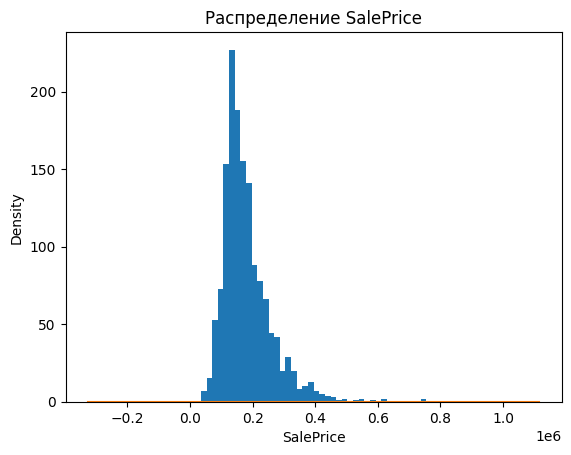

In [23]:
#20.	Построить гистограмму SalePrice + распределение (Seaborn distplot).
plt.figure()
plt.hist(db['SalePrice'], bins=40)
db['SalePrice'].plot(kind='kde')

plt.xlabel('SalePrice')
plt.ylabel('Density')
plt.title('Распределение SalePrice')
plt.show()

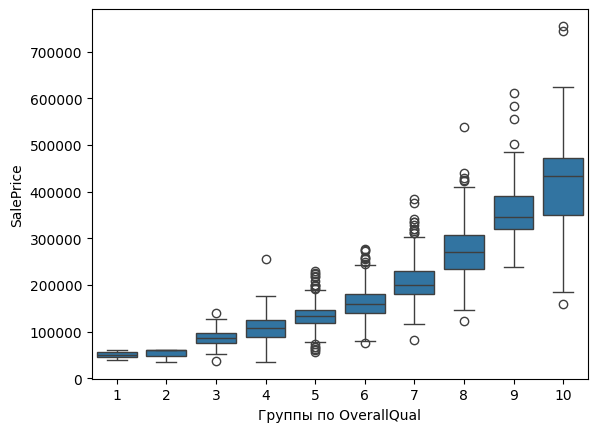

In [24]:
#21.	Построить boxplot: OverallQual vs SalePrice.
sns.boxplot(data=db, x='OverallQual', y='SalePrice')
plt.xlabel('Группы по OverallQual')
plt.show()

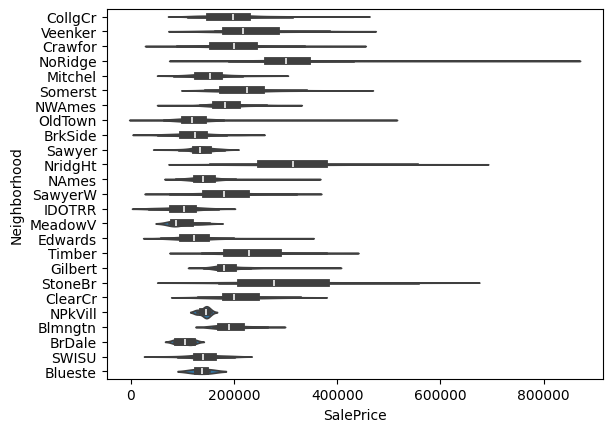

In [25]:
#22.	Построить violinplot: Neighborhood vs SalePrice.
sns.violinplot(data=db, x='SalePrice', y='Neighborhood')
plt.show()

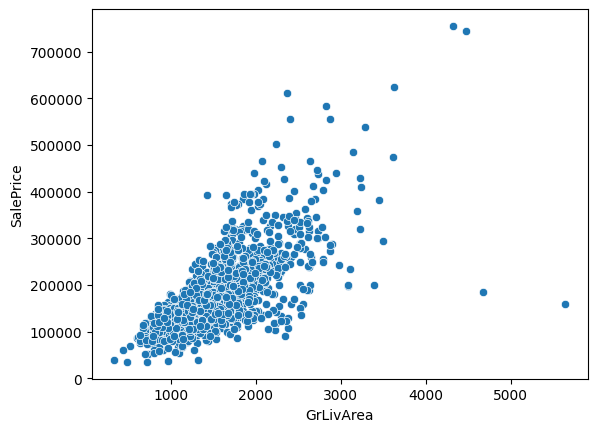

In [26]:
#24.	Построить scatterplot: •	GrLivArea vs SalePrice •	TotalBsmtSF vs SalePrice •	YearBuilt vs SalePrice
sns.scatterplot(data=db, x='GrLivArea', y='SalePrice')
plt.show()


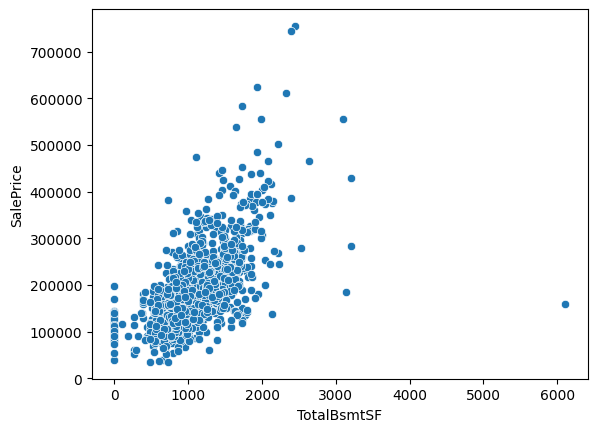

In [27]:
sns.scatterplot(data=db, x='TotalBsmtSF', y='SalePrice')
plt.show()

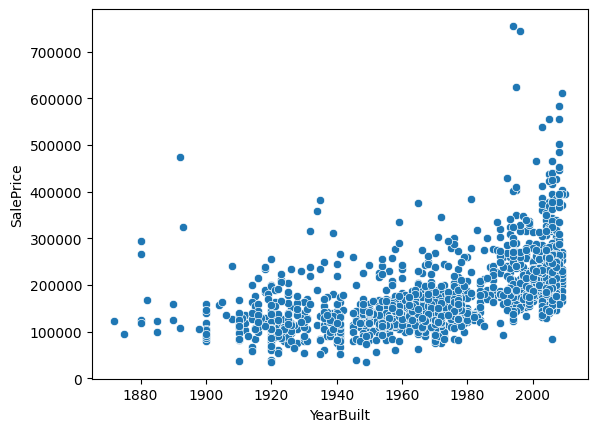

In [28]:
sns.scatterplot(data=db, x='YearBuilt', y='SalePrice')
plt.show()

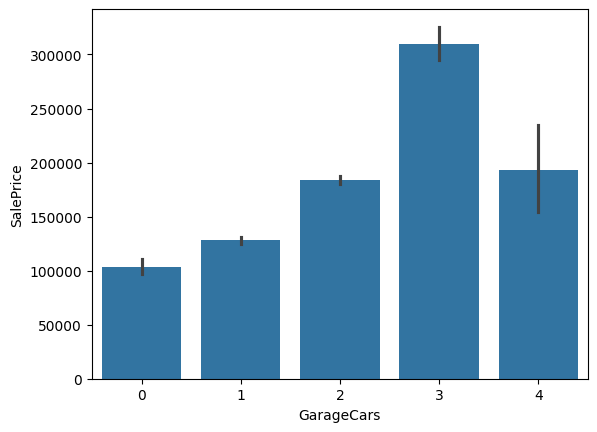

In [29]:
#25.	Построить barplot: средняя цена по GarageCars.
sns.barplot(data=db, x='GarageCars', y='SalePrice')
plt.show()

ЭТАП 2: Предобработка данных

In [30]:
#28.	Обработать пропущенные значения (если есть).
db.isnull().sum()

,0
GrLivArea,0
YearBuilt,0
GarageCars,0
TotalBsmtSF,0
FullBath,0
OverallQual,0
Neighborhood,0
SalePrice,0


In [31]:
#29.	Преобразовать Neighborhood в числовой (one-hot или LabelEncoder).
db = pd.get_dummies(db, columns=['Neighborhood'], drop_first=True).astype(int)

In [32]:
db

,GrLivArea,YearBuilt,GarageCars,TotalBsmtSF,FullBath,OverallQual,SalePrice,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,1710,2003,2,856,2,7,208500,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1262,1976,2,1262,2,6,181500,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1786,2001,2,920,2,7,223500,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1717,1915,3,756,1,7,140000,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2198,2000,3,1145,2,8,250000,0,0,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1647,1999,2,953,2,6,175000,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1456,2073,1978,2,1542,2,6,210000,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1457,2340,1941,1,1152,2,7,266500,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1458,1078,1950,1,1078,1,5,142125,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
#30.	Нормализовать числовые признаки (MinMaxScaler или StandardScaler).
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features = db.drop(columns=['SalePrice'])
scaled_data = scaler.fit_transform(features)

In [34]:
scaled_data

array([[ 0.37033344,  1.05099379,  0.31172464, ..., -0.13199092,
        -0.16347148, -0.08712888],
       [-0.48251191,  0.15673371,  0.31172464, ..., -0.13199092,
        -0.16347148, 11.47725023],
       [ 0.51501256,  0.9847523 ,  0.31172464, ..., -0.13199092,
        -0.16347148, -0.08712888],
       ...,
       [ 1.56964722, -1.00249232, -1.02685765, ..., -0.13199092,
        -0.16347148, -0.08712888],
       [-0.83278768, -0.70440562, -1.02685765, ..., -0.13199092,
        -0.16347148, -0.08712888],
       [-0.49393395, -0.20759447, -1.02685765, ..., -0.13199092,
        -0.16347148, -0.08712888]])

In [35]:
#32.	Разделить данные на X и y, где y = SalePrice.
x = scaled_data
y = db['SalePrice']

In [36]:
#33.	Разбить данные на train/test (train_test_split, 80/20).
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [37]:
x_test.shape

(292, 30)

In [38]:
#34.	Построить модель LinearRegression() из sklearn.linear_model.
from sklearn.linear_model import LinearRegression

model = LinearRegression()


In [39]:
model.fit(x_train, y_train)

LinearRegression()

In [40]:
y_pred = model.predict(x_test)

In [41]:
from sklearn.metrics import r2_score

r2_score(y_test, y_pred)

0.8267380266474198

In [42]:
import joblib

joblib.dump(model, '../models/house_model.pkl')
joblib.dump(scaler, '../models/house_scaler.pkl')

['house_scaler.pkl']

In [43]:
db.columns

Index(['GrLivArea', 'YearBuilt', 'GarageCars', 'TotalBsmtSF', 'FullBath',
       'OverallQual', 'SalePrice', 'Neighborhood_Blueste',
       'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr',
       'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards',
       'Neighborhood_Gilbert', 'Neighborhood_IDOTRR', 'Neighborhood_MeadowV',
       'Neighborhood_Mitchel', 'Neighborhood_NAmes', 'Neighborhood_NPkVill',
       'Neighborhood_NWAmes', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt',
       'Neighborhood_OldTown', 'Neighborhood_SWISU', 'Neighborhood_Sawyer',
       'Neighborhood_SawyerW', 'Neighborhood_Somerst', 'Neighborhood_StoneBr',
       'Neighborhood_Timber', 'Neighborhood_Veenker'],
      dtype='object')

In [44]:
db

,GrLivArea,YearBuilt,GarageCars,TotalBsmtSF,FullBath,OverallQual,SalePrice,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,1710,2003,2,856,2,7,208500,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1262,1976,2,1262,2,6,181500,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1786,2001,2,920,2,7,223500,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1717,1915,3,756,1,7,140000,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2198,2000,3,1145,2,8,250000,0,0,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1647,1999,2,953,2,6,175000,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1456,2073,1978,2,1542,2,6,210000,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1457,2340,1941,1,1152,2,7,266500,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1458,1078,1950,1,1078,1,5,142125,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [45]:
db

,GrLivArea,YearBuilt,GarageCars,TotalBsmtSF,FullBath,OverallQual,SalePrice,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,1710,2003,2,856,2,7,208500,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1262,1976,2,1262,2,6,181500,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1786,2001,2,920,2,7,223500,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1717,1915,3,756,1,7,140000,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2198,2000,3,1145,2,8,250000,0,0,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1647,1999,2,953,2,6,175000,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1456,2073,1978,2,1542,2,6,210000,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1457,2340,1941,1,1152,2,7,266500,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1458,1078,1950,1,1078,1,5,142125,0,0,0,...,0,0,0,0,0,0,0,0,0,0
